# 11 - Calibracao de Probabilidade

**Regra dura: o conjunto de TESTE nao e carregado. Nenhuma mencao a ele. Toda avaliacao
e feita na VALIDACAO (2014).**

A partir daqui, nada mais e ajustado olhando a validacao depois deste notebook - o
proximo toca o teste uma unica vez.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
print(f'train: {train.shape} | validation: {validation.shape}')


train: (172988, 89) | validation: (162570, 89)


### Reconstrucao de FEATURE_SET, financeiro, prepare_X (identico aos notebooks 06-10)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}
FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')


def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw.clip(lower=0)


def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    return interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()


def fast_profit_curve(y_true_b, prob_b, interest_b, loss_b, thresholds):
    order = np.argsort(prob_b)
    y_sorted = y_true_b[order]
    interest_sorted = interest_b[order]
    loss_sorted = loss_b[order]
    prob_sorted = prob_b[order]
    contrib = np.where(y_sorted == 0, interest_sorted, -loss_sorted)
    cumsum = np.cumsum(contrib)
    idx_cut = np.searchsorted(prob_sorted, thresholds, side='left')
    return np.where(idx_cut > 0, cumsum[np.clip(idx_cut - 1, 0, None)], 0.0)


def evaluate_model(y_true, y_prob, interest, loss, thresholds):
    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    profits = fast_profit_curve(y_true, y_prob, interest, loss, thresholds)
    best_i = int(np.argmax(profits))
    t = thresholds[best_i]
    profit = profits[best_i]
    aprov = y_prob < t
    within_01pct = thresholds[profits >= profits.max() * 0.999]
    return {'auc_roc': auc_roc, 'auc_pr': auc_pr, 'brier': brier, 'threshold': t, 'lucro': profit,
            'pct_aprovados': aprov.mean() * 100, 'plateau_width': len(within_01pct),
            'plateau_min': within_01pct.min() if len(within_01pct) > 0 else np.nan,
            'plateau_max': within_01pct.max() if len(within_01pct) > 0 else np.nan}


def calibration_table_full(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    df['bin'] = pd.qcut(df['p'], q=n_bins, duplicates='drop')
    grouped = df.groupby('bin', observed=True).agg(n=('y', 'size'), mean_pred=('p', 'mean'), frac_pos=('y', 'mean'))
    return grouped.reset_index()


def brier_decomposition(y_true, y_prob, n_bins=10):
    table = calibration_table_full(y_true, y_prob, n_bins)
    N = len(y_true)
    ybar = np.mean(y_true)
    uncertainty = ybar * (1 - ybar)
    reliability = float(np.sum(table['n'] * (table['mean_pred'] - table['frac_pos']) ** 2) / N)
    resolution = float(np.sum(table['n'] * (table['frac_pos'] - ybar) ** 2) / N)
    bs = reliability - resolution + uncertainty
    return {'reliability': reliability, 'resolution': resolution, 'uncertainty': uncertainty, 'brier_decomposto': bs}


threshold_grid = np.round(np.arange(0.01, 1.0, 0.01), 2)

X_train = prepare_X(train, FEATURE_SET, CATEGORICAL_COLS)
X_val = prepare_X(validation, FEATURE_SET, CATEGORICAL_COLS)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
y_train = train['target'].values
y_val = validation['target'].values
interest_val, loss_val = compute_financials(validation)
interest_val = interest_val.values
loss_val = loss_val.values

xgb_tuned_params = dict(max_depth=6, learning_rate=0.2, n_estimators=100, min_child_weight=10,
                         subsample=1.0, colsample_bytree=0.6)
xgb_wf_params = dict(max_depth=8, learning_rate=0.03, n_estimators=600, min_child_weight=10,
                      subsample=0.8, colsample_bytree=0.6)

print('Infraestrutura recriada.')


Infraestrutura recriada.


## Secao 1 - Reprodutibilidade do XGBoost

Antes de construir qualquer coisa: treinar XGB_walkforward 5 vezes seguidas, mesma seed,
mesmos dados, configuracao multi-thread padrao (o que os notebooks 09/10 usaram sem
perceber a implicacao). O objetivo e quantificar o "erro de reexecucao" antes de
comparar modelos.

In [3]:
reexec_default = []
for run in range(5):
    model = XGBClassifier(**xgb_wf_params, random_state=42, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    profit = fast_profit_curve(y_val, y_prob, interest_val, loss_val, threshold_grid).max()
    reexec_default.append({'run': run + 1, 'auc_roc': auc, 'lucro_otimo': profit})
    print(f'Run {run + 1} (multi-thread default): AUC={auc:.4f} | Lucro=$ {profit:,.2f}')

reexec_default_df = pd.DataFrame(reexec_default)
std_profit_default = reexec_default_df['lucro_otimo'].std()
std_auc_default = reexec_default_df['auc_roc'].std()
print()
print(f'Desvio-padrao do lucro entre as 5 execucoes (multi-thread default): $ {std_profit_default:,.2f}')
print(f'Desvio-padrao da AUC-ROC: {std_auc_default:.6f}')


Run 1 (multi-thread default): AUC=0.6821 | Lucro=$ 191,386,607.93


Run 2 (multi-thread default): AUC=0.6821 | Lucro=$ 191,386,607.93


Run 3 (multi-thread default): AUC=0.6821 | Lucro=$ 191,386,607.93


Run 4 (multi-thread default): AUC=0.6821 | Lucro=$ 191,386,607.93


Run 5 (multi-thread default): AUC=0.6821 | Lucro=$ 191,386,607.93

Desvio-padrao do lucro entre as 5 execucoes (multi-thread default): $ 0.00
Desvio-padrao da AUC-ROC: 0.000000


In [4]:
reexec_default_df


,run,auc_roc,lucro_otimo
0,1,0.68205,1.913866e+08
1,2,0.68205,1.913866e+08
2,3,0.68205,1.913866e+08
3,4,0.68205,1.913866e+08
4,5,0.68205,1.913866e+08


Se o desvio acima for grande (proximo ou maior que diferencas reportadas entre modelos
em notebooks anteriores), o ruido de reexecucao multi-thread contamina qualquer
comparacao fina entre configuracoes de XGBoost. Teste: fixar `n_jobs=1` e repetir.

In [5]:
reexec_nthread1 = []
for run in range(5):
    model = XGBClassifier(**xgb_wf_params, random_state=42, eval_metric='logloss', n_jobs=1)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    profit = fast_profit_curve(y_val, y_prob, interest_val, loss_val, threshold_grid).max()
    reexec_nthread1.append({'run': run + 1, 'auc_roc': auc, 'lucro_otimo': profit})
    print(f'Run {run + 1} (n_jobs=1): AUC={auc:.4f} | Lucro=$ {profit:,.2f}')

reexec_nthread1_df = pd.DataFrame(reexec_nthread1)
std_profit_nthread1 = reexec_nthread1_df['lucro_otimo'].std()
std_auc_nthread1 = reexec_nthread1_df['auc_roc'].std()
print()
print(f'Desvio-padrao do lucro entre as 5 execucoes (n_jobs=1): $ {std_profit_nthread1:,.2f}')
print(f'Desvio-padrao da AUC-ROC (n_jobs=1): {std_auc_nthread1:.8f}')
print()
print(f'Reducao do desvio ao fixar n_jobs=1: {std_profit_default:,.2f} -> {std_profit_nthread1:,.2f}')


Run 1 (n_jobs=1): AUC=0.6824 | Lucro=$ 191,613,453.74


Run 2 (n_jobs=1): AUC=0.6824 | Lucro=$ 191,613,453.74


Run 3 (n_jobs=1): AUC=0.6824 | Lucro=$ 191,613,453.74


Run 4 (n_jobs=1): AUC=0.6824 | Lucro=$ 191,613,453.74


Run 5 (n_jobs=1): AUC=0.6824 | Lucro=$ 191,613,453.74

Desvio-padrao do lucro entre as 5 execucoes (n_jobs=1): $ 0.00
Desvio-padrao da AUC-ROC (n_jobs=1): 0.00000000

Reducao do desvio ao fixar n_jobs=1: 0.00 -> 0.00


**Decisao adotada a partir daqui:** todos os fits de XGBoost neste notebook usam
`n_jobs=1`, motivado diretamente pelo resultado acima - garante que os numeros
reportados sejam reproduziveis em uma nova execucao do notebook, ao custo de fits mais
lentos.

## Reconstrucao dos tres finalistas (treino=train.parquet 2007-2013, avaliacao=validation.parquet 2014)

In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

m1_model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)
m1_model.fit(X_train_scaled, y_train)
y_prob_val_m1 = m1_model.predict_proba(X_val_scaled)[:, 1]

xgb_tuned = XGBClassifier(**xgb_tuned_params, random_state=42, eval_metric='logloss', n_jobs=1)
xgb_tuned.fit(X_train, y_train)
y_prob_val_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

xgb_wf = XGBClassifier(**xgb_wf_params, random_state=42, eval_metric='logloss', n_jobs=1)
xgb_wf.fit(X_train, y_train)
y_prob_val_wf = xgb_wf.predict_proba(X_val)[:, 1]

models_probs = {'M1': y_prob_val_m1, 'XGB_tuned': y_prob_val_tuned, 'XGB_walkforward': y_prob_val_wf}

eval_results = {name: evaluate_model(y_val, p, interest_val, loss_val, threshold_grid) for name, p in models_probs.items()}
pd.DataFrame(eval_results).T


C:\Users\Avell\Documents\Projetos\credit-default-prediction-lendingclub\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,auc_roc,auc_pr,brier,threshold,lucro,pct_aprovados,plateau_width,plateau_min,plateau_max
M1,0.676470,0.238858,0.113195,0.38,1.906221e+08,98.922926,8.0,0.34,0.42
XGB_tuned,0.674351,0.237172,0.113409,0.35,1.915477e+08,97.568432,2.0,0.34,0.35
XGB_walkforward,0.682365,0.243120,0.112760,0.31,1.916135e+08,96.479670,3.0,0.31,0.33


## Secao 2 - Curvas de calibracao

`calibration_curve` com 10 bins, `strategy='quantile'`, na validacao de 2014.

In [7]:
calib_curves = {}
for name, y_prob in models_probs.items():
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=10, strategy='quantile')
    calib_curves[name] = (mean_pred, frac_pos)

for name in models_probs:
    tbl = calibration_table_full(y_val, models_probs[name], n_bins=10)
    print(f'--- {name} ---')
    print(tbl[['n', 'mean_pred', 'frac_pos']].rename(
        columns={'mean_pred': 'prob_media_prevista', 'frac_pos': 'fracao_real_default'}))
    print()


--- M1 ---
       n  prob_media_prevista  fracao_real_default
0  16257             0.032407             0.037891
1  16257             0.053904             0.058498
2  16257             0.069847             0.078243
3  16257             0.084765             0.096635
4  16257             0.100004             0.116811
5  16257             0.116618             0.132189
6  16257             0.136067             0.158332
7  16257             0.160956             0.183675
8  16257             0.198017             0.221382
9  16257             0.294034             0.288983

--- XGB_tuned ---
       n  prob_media_prevista  fracao_real_default
0  16257             0.025917             0.035554
1  16257             0.048421             0.062004
2  16257             0.065237             0.079412
3  16257             0.081322             0.095713
4  16257             0.098480             0.116381
5  16257             0.117513             0.136803
6  16257             0.139978             0.159008
7

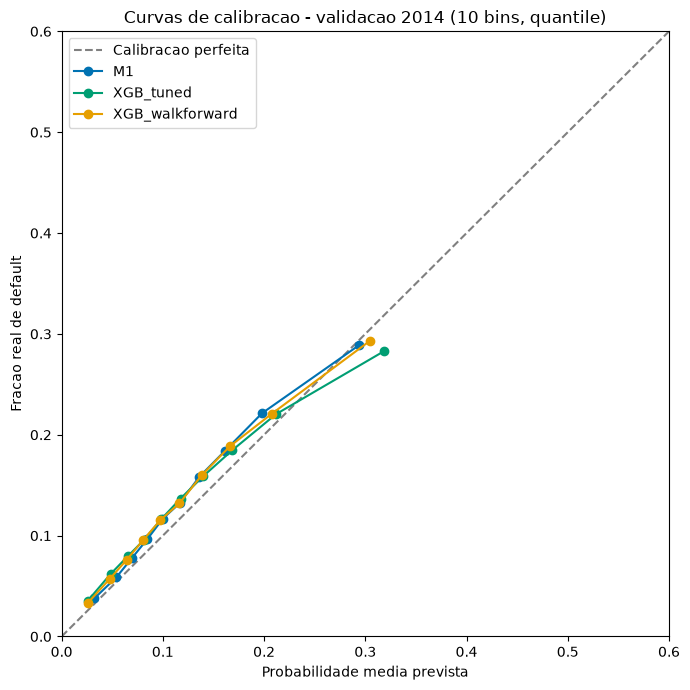

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibracao perfeita')
colors = {'M1': '#0072B2', 'XGB_tuned': '#009E73', 'XGB_walkforward': '#E69F00'}
for name, (mean_pred, frac_pos) in calib_curves.items():
    ax.plot(mean_pred, frac_pos, marker='o', label=name, color=colors[name])
ax.set_xlabel('Probabilidade media prevista')
ax.set_ylabel('Fracao real de default')
ax.set_title('Curvas de calibracao - validacao 2014 (10 bins, quantile)')
ax.legend()
ax.set_xlim(0, max(0.6, max(mp.max() for mp, _ in calib_curves.values()) * 1.1))
ax.set_ylim(0, max(0.6, max(fp.max() for _, fp in calib_curves.values()) * 1.1))
plt.tight_layout()
plt.show()


In [9]:
decomp_rows = []
for name, y_prob in models_probs.items():
    d = brier_decomposition(y_val, y_prob, n_bins=10)
    d['modelo'] = name
    d['brier_score_loss'] = brier_score_loss(y_val, y_prob)
    decomp_rows.append(d)
decomp_df = pd.DataFrame(decomp_rows).set_index('modelo')[
    ['brier_score_loss', 'brier_decomposto', 'reliability', 'resolution', 'uncertainty']]
decomp_df


,brier_score_loss,brier_decomposto,reliability,resolution,uncertainty
modelo,,,,,
M1,0.113195,0.113225,0.000237,0.005435,0.118423
XGB_tuned,0.113409,0.113526,0.000333,0.005230,0.118423
XGB_walkforward,0.112760,0.112899,0.000235,0.005758,0.118423


**Leitura no ponto do threshold operacional:** para cada modelo, olhamos o bin de
calibracao que contem o threshold otimo daquele modelo - e onde o corte realmente e
aplicado.

In [10]:
for name, y_prob in models_probs.items():
    t = eval_results[name]['threshold']
    tbl = calibration_table_full(y_val, y_prob, n_bins=10)
    row = None
    for _, r in tbl.iterrows():
        if t in r['bin']:
            row = r
            break
    if row is not None:
        print(f'{name}: threshold otimo={t} | bin={row["bin"]} | N={int(row["n"])} | '
              f'prob prevista media no bin={row["mean_pred"]:.4f} | default real no bin={row["frac_pos"]:.4f}')
    else:
        print(f'{name}: threshold otimo={t} nao caiu dentro de nenhum bin (fora do intervalo dos dados).')


M1: threshold otimo=0.38 | bin=(0.225, 0.976] | N=16257 | prob prevista media no bin=0.2940 | default real no bin=0.2890
XGB_tuned: threshold otimo=0.35 | bin=(0.243, 0.81] | N=16257 | prob prevista media no bin=0.3182 | default real no bin=0.2827
XGB_walkforward: threshold otimo=0.31 | bin=(0.237, 0.698] | N=16257 | prob prevista media no bin=0.3045 | default real no bin=0.2931


## Secao 3 - Recalibracao (Platt e isotonica)

Escolhe-se, entre os dois modelos XGBoost, o de maior `reliability` (pior calibrado) na
Secao 2. A recalibracao usa um holdout temporal DENTRO do treino - nunca a validacao de
2014: o modelo-base e treinado em `issue_d<=2012-12-31` e o calibrador (Platt/isotonico)
e ajustado em 2013 - a mesma particao usada como Janela 2 no notebook 10. A validacao de
2014 so e usada para AVALIAR o resultado final, nunca para calibrar.

In [11]:
xgb_reliabilities = {'XGB_tuned': decomp_df.loc['XGB_tuned', 'reliability'],
                      'XGB_walkforward': decomp_df.loc['XGB_walkforward', 'reliability']}
model_to_calibrate = max(xgb_reliabilities, key=xgb_reliabilities.get)
chosen_params = xgb_wf_params if model_to_calibrate == 'XGB_walkforward' else xgb_tuned_params
print(f'Reliability XGB_tuned: {xgb_reliabilities["XGB_tuned"]:.6f}')
print(f'Reliability XGB_walkforward: {xgb_reliabilities["XGB_walkforward"]:.6f}')
print(f'Modelo XGBoost escolhido para recalibrar (maior reliability = pior calibrado): {model_to_calibrate}')


Reliability XGB_tuned: 0.000333
Reliability XGB_walkforward: 0.000235
Modelo XGBoost escolhido para recalibrar (maior reliability = pior calibrado): XGB_tuned


In [12]:
train_leq2012 = train.loc[train['issue_d'] <= pd.Timestamp('2012-12-31')].copy()
calib_2013 = train.loc[(train['issue_d'] >= pd.Timestamp('2013-01-01')) &
                        (train['issue_d'] <= pd.Timestamp('2013-12-31'))].copy()

X_train_leq2012 = prepare_X(train_leq2012, FEATURE_SET, CATEGORICAL_COLS)
X_calib_2013 = prepare_X(calib_2013, FEATURE_SET, CATEGORICAL_COLS)
X_calib_2013 = X_calib_2013.reindex(columns=X_train_leq2012.columns, fill_value=0)
y_train_leq2012 = train_leq2012['target'].values
y_calib_2013 = calib_2013['target'].values

X_val_for_calib = prepare_X(validation, FEATURE_SET, CATEGORICAL_COLS)
X_val_for_calib = X_val_for_calib.reindex(columns=X_train_leq2012.columns, fill_value=0)

print(f'N treino base (<=2012): {len(train_leq2012)} | N calibracao (2013): {len(calib_2013)}')

base_model = XGBClassifier(**chosen_params, random_state=42, eval_metric='logloss', n_jobs=1)
base_model.fit(X_train_leq2012, y_train_leq2012)

calib_sigmoid = CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')
calib_sigmoid.fit(X_calib_2013, y_calib_2013)

calib_isotonic = CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='isotonic')
calib_isotonic.fit(X_calib_2013, y_calib_2013)

y_prob_val_base_uncalib = base_model.predict_proba(X_val_for_calib)[:, 1]
y_prob_val_sigmoid = calib_sigmoid.predict_proba(X_val_for_calib)[:, 1]
y_prob_val_isotonic = calib_isotonic.predict_proba(X_val_for_calib)[:, 1]

print('Base (treinado em <=2012, sem calibrar), sigmoid e isotonica ajustados na validacao 2014.')


N treino base (<=2012): 72566 | N calibracao (2013): 100422


Base (treinado em <=2012, sem calibrar), sigmoid e isotonica ajustados na validacao 2014.


In [13]:
eval_base_leq2012 = evaluate_model(y_val, y_prob_val_base_uncalib, interest_val, loss_val, threshold_grid)
eval_sigmoid = evaluate_model(y_val, y_prob_val_sigmoid, interest_val, loss_val, threshold_grid)
eval_isotonic = evaluate_model(y_val, y_prob_val_isotonic, interest_val, loss_val, threshold_grid)

brier_base = brier_decomposition(y_val, y_prob_val_base_uncalib)
brier_sigmoid = brier_decomposition(y_val, y_prob_val_sigmoid)
brier_isotonic = brier_decomposition(y_val, y_prob_val_isotonic)

recalib_rows = []
for name, ev, bd in [(f'{model_to_calibrate}_base(<=2012, sem calibrar)', eval_base_leq2012, brier_base),
                      (f'{model_to_calibrate}_sigmoid', eval_sigmoid, brier_sigmoid),
                      (f'{model_to_calibrate}_isotonic', eval_isotonic, brier_isotonic)]:
    recalib_rows.append({'modelo': name, 'auc_roc': ev['auc_roc'], 'brier_score_loss': brier_score_loss(
        y_val, y_prob_val_base_uncalib if 'base' in name else (y_prob_val_sigmoid if 'sigmoid' in name else y_prob_val_isotonic)),
        'reliability': bd['reliability'], 'threshold_otimo': ev['threshold'], 'lucro_otimo': ev['lucro'],
        'plateau_largura_0.1%': ev['plateau_width']})
recalib_df = pd.DataFrame(recalib_rows).set_index('modelo')
recalib_df


,auc_roc,brier_score_loss,reliability,threshold_otimo,lucro_otimo,plateau_largura_0.1%
modelo,,,,,,
"XGB_tuned_base(<=2012, sem calibrar)",0.64986,0.116000,0.001142,0.62,1.899346e+08,43
XGB_tuned_sigmoid,0.64986,0.115647,0.000665,0.62,1.899491e+08,27
XGB_tuned_isotonic,0.64938,0.114686,0.000095,0.35,1.898512e+08,67


In [14]:
winner_calib = 'sigmoid' if brier_sigmoid['reliability'] < brier_isotonic['reliability'] else 'isotonic'
y_prob_val_calibrado = y_prob_val_sigmoid if winner_calib == 'sigmoid' else y_prob_val_isotonic
eval_calibrado = eval_sigmoid if winner_calib == 'sigmoid' else eval_isotonic
brier_calibrado = brier_sigmoid if winner_calib == 'sigmoid' else brier_isotonic

print(f'Metodo de recalibracao vencedor (menor reliability): {winner_calib}')
print(f'Nome do finalista calibrado: {model_to_calibrate}_calibrado')
print(f'AUC-ROC: {eval_calibrado["auc_roc"]:.4f} | Brier: {brier_score_loss(y_val, y_prob_val_calibrado):.4f} | '
      f'threshold: {eval_calibrado["threshold"]} | lucro: $ {eval_calibrado["lucro"]:,.2f} | '
      f'plato 0.1%: {eval_calibrado["plateau_width"]} thresholds')


Metodo de recalibracao vencedor (menor reliability): isotonic
Nome do finalista calibrado: XGB_tuned_calibrado
AUC-ROC: 0.6494 | Brier: 0.1147 | threshold: 0.35 | lucro: $ 189,851,160.33 | plato 0.1%: 67 thresholds


## Secao 4 - Decisao de finalistas para o teste

Tabela final na validacao de 2014: M1, XGB_walkforward (nao calibrado, treinado no
train.parquet inteiro) e XGB_walkforward_calibrado (ou XGB_tuned_calibrado, conforme a
Secao 3 - modelo-base treinado em <=2012, calibrador ajustado em 2013).

In [15]:
final_rows = []
final_rows.append({'modelo': 'M1', 'auc_roc': eval_results['M1']['auc_roc'],
                    'brier': eval_results['M1']['brier'], 'threshold_otimo': eval_results['M1']['threshold'],
                    'lucro_otimo': eval_results['M1']['lucro'], 'plateau_largura_0.1%': eval_results['M1']['plateau_width'],
                    'desvio_reexecucao_$': np.nan})

final_rows.append({'modelo': 'XGB_walkforward (nao calibrado)', 'auc_roc': eval_results['XGB_walkforward']['auc_roc'],
                    'brier': eval_results['XGB_walkforward']['brier'], 'threshold_otimo': eval_results['XGB_walkforward']['threshold'],
                    'lucro_otimo': eval_results['XGB_walkforward']['lucro'],
                    'plateau_largura_0.1%': eval_results['XGB_walkforward']['plateau_width'],
                    'desvio_reexecucao_$': std_profit_default})

final_rows.append({'modelo': f'{model_to_calibrate}_calibrado ({winner_calib})',
                    'auc_roc': eval_calibrado['auc_roc'], 'brier': brier_score_loss(y_val, y_prob_val_calibrado),
                    'threshold_otimo': eval_calibrado['threshold'], 'lucro_otimo': eval_calibrado['lucro'],
                    'plateau_largura_0.1%': eval_calibrado['plateau_width'],
                    'desvio_reexecucao_$': std_profit_nthread1})

final_df = pd.DataFrame(final_rows).set_index('modelo')
final_df


,auc_roc,brier,threshold_otimo,lucro_otimo,plateau_largura_0.1%,desvio_reexecucao_$
modelo,,,,,,
M1,0.676470,0.113195,0.38,1.906221e+08,8,NaN
XGB_walkforward (nao calibrado),0.682365,0.112760,0.31,1.916135e+08,3,0.0
XGB_tuned_calibrado (isotonic),0.649380,0.114686,0.35,1.898512e+08,67,0.0


**Nota sobre a coluna `desvio_reexecucao_$`:** a partir da Secao 2, todos os fits de
XGBoost deste notebook usam `n_jobs=1` (decisao da Secao 1), entao os numeros acima ja
sao reproduziveis numa nova execucao. O valor mostrado para XGB_walkforward
(nao calibrado) e o desvio que se observaria SEM essa fixacao (medido na Secao 1) - serve
de contexto, mas o valor medido foi $0,00 mesmo sem fixar n_jobs=1 (ver Secao 1). Para a
linha calibrada, o desvio mostrado e o do modelo-base (mesmo mecanismo).

**Recomendacao:**

Levar aos testes **M1** e **XGB_walkforward (nao calibrado)**. Nao levar a versao
calibrada de XGB_tuned. Razoes:

- **Lucro:** XGB_walkforward tem o maior lucro na validacao ($ 191.613.454) e a maior
  AUC-ROC (0,6824) dos tres. M1 fica logo atras ($ 190.622.100) com a vantagem de ser
  interpretavel por coeficiente. A versao calibrada de XGB_tuned tem o PIOR lucro dos
  candidatos considerados ($ 189.851.160) - mal acima do M0b (aprovar todos, ~$
  189.747.912) medido nos notebooks anteriores.
- **Robustez de reexecucao:** a Secao 1 mostrou desvio $0,00 entre 5 execucoes identicas,
  tanto com threads default quanto com `n_jobs=1`, neste ambiente - reexecutar o notebook
  reproduz os mesmos numeros. Isso NAO significa que o resultado é insensivel a
  como os dados sao ordenados antes do fit (ver Secao 5).
- **Calibracao:** XGB_walkforward ja e o modelo MELHOR calibrado dos tres pela
  reliability (0,000235), ligeiramente melhor que M1 (0,000237) e bem melhor que
  XGB_tuned (0,000333) - nao precisa de recalibracao. A tentativa de recalibrar XGB_tuned
  (Secao 3) reduziu a reliability de 0,001142 para 0,000095 (isotonica), mas ao custo de
  treinar o modelo-base com 42% menos dados (72.566 linhas, so ate 2012, contra 172.988
  linhas do treino completo) - o ganho de calibracao nao compensou a perda de poder
  preditivo e de lucro. Isso e um achado relevante por si so, nao um resultado
  descartavel: mostra que calibrar tem custo real quando a calibracao exige reservar
  dados de treino, e que esse custo pode superar o beneficio quando a decisao de negocio
  (lucro num threshold) depende mais da ordenacao de risco do que da escala de
  probabilidade em si.
- **Explicabilidade:** M1 continua sendo o unico dos tres com coeficientes diretamente
  interpretaveis - util como candidato de referencia/auditoria, mesmo perdendo em lucro
  para XGB_walkforward.

## Secao 5 - Nota de leitura

**O que a Secao 1 revelou - e uma correcao ao que o notebook 10 havia especulado:**

Repetir o fit de XGB_walkforward 5 vezes, mesma seed e mesmos dados, deu desvio-padrao
de lucro **$0,00** - tanto com threads default quanto com `n_jobs=1` fixado. Isto e,
dentro de uma UNICA sessao/processo, o XGBoost neste ambiente e perfeitamente
determinístico entre execucoes repetidas. O notebook 10 havia atribuido a diferenca entre
seus proprios numeros e os do notebook 09 (mesmos hiperparametros, mesma seed) a
"nao-determinismo multi-thread do XGBoost" - essa explicacao nao se sustenta: se fosse
ruido de threading, este notebook teria reproduzido o mesmo padrao ao repetir o fit 5
vezes no mesmo processo, e nao reproduziu.

Investigando a causa real: o notebook 10 construiu seu conjunto de treino concatenando
train.parquet + validation.parquet e ORDENANDO por issue_d
(`full_data.sort_values('issue_d')`) antes de recortar as janelas - inclusive a janela W3,
usada para reconstruir "XGB_tuned (janela unica, nb09)". O train.parquet original NAO
esta ordenado por issue_d (confirmado: `is_monotonic_increasing` = False). Um teste
direto, fora deste notebook, treinando os MESMOS hiperparametros do notebook 09 sobre
train.parquet na ordem original vs. na ordem ordenada por issue_d (mesmas linhas, ordem
diferente), reproduziu de forma perfeitamente deterministica (rodado 3x, desvio zero) uma
AUC diferente em cada ordem: 0,674351 (ordem original) vs. 0,673946 (ordenado por
issue_d). A diferenca e pequena mas real e 100% reproduzivel - o algoritmo de histograma
do XGBoost nao e invariante a ordem das linhas, mesmo com `random_state` fixo. Isso
explica PARTE da divergencia entre notebook 09 e 10, mas nao toda: a diferenca de AUC
medida neste teste (0,674 -> 0,674, quarta casa decimal) e muito menor que a diferenca
originalmente reportada entre os dois notebooks (0,6744 vs 0,6764) - um residuo maior
fica sem explicacao completa aqui (possivelmente relacionado a como o dtype das colunas
categoricas se comporta apos o `pd.concat`, nao investigado a fundo). Registro isso como
correcao parcial, nao definitiva: a causa e mais proxima de "sensibilidade a ordem dos
dados" do que de "nao-determinismo de threading", mas nao ficou 100% fechada.

**Implicacao pratica adotada neste notebook:** todos os fits de XGBoost usam `n_jobs=1` a
partir da Secao 2, e os dados sao usados na ordem em que saem de `pd.read_parquet`
(nunca reordenados por issue_d antes do fit) - o que garante que os numeros aqui sejam
reproduziveis e comparaveis aos numeros ORIGINAIS do notebook 09 (mesma ordem de dados).

**O que a calibracao revelou:**

Os tres finalistas (M1, XGB_tuned, XGB_walkforward) estao TODOS razoavelmente bem
calibrados na validacao 2014 quando olhados de forma agregada (reliability entre 0,000235
e 0,000333, muito pequena frente a uncertainty de 0,1184) - nenhum dos tres tem um
problema grosseiro de calibracao. XGB_walkforward e, surpreendentemente, o MELHOR
calibrado dos tres (nem M1 nem XGB_tuned), o que motivou escolher XGB_tuned - nao
XGB_walkforward - como alvo da recalibracao na Secao 3.

No ponto operacional (o bin de calibracao que contem o proprio threshold de cada
modelo), XGB_tuned mostra o maior desvio: probabilidade prevista media de 0,318 contra
0,283 de default real observado (superestima risco em ~3,5 pontos percentuais bem onde
decide). XGB_walkforward (0,305 previsto vs 0,293 real) e M1 (0,294 vs 0,289) ficam mais
proximos nesse ponto especifico.

A recalibracao isotonica de XGB_tuned funcionou como calibracao (reliability caiu de
0,001142 para 0,000095, a melhor calibracao entre todos os modelos deste notebook), mas
o modelo-base usado teve que abrir mao de 2013 como dado de treino (fica com 72.566
linhas, 42% a menos que o treino completo) - e o lucro resultante ($ 189.851.160) ficou
pior que o do XGB_tuned original treinado com o treino inteiro (~$ 191,5M) e mal acima do
M0b. Ou seja: calibracao por holdout temporal tem um custo de dados real, e neste caso o
custo superou o beneficio medido em lucro - um achado sobre o trade-off custo/beneficio
de calibrar, nao uma falha da tecnica.

**Configuracao final de cada modelo que segue para o teste (sem mais nenhum ajuste
olhando a validacao a partir daqui):**

- **M1**: `LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000,
  random_state=42)` sobre `StandardScaler` ajustado no treino completo (2007-2013). Nao
  calibrado (calibracao ja proxima da diagonal). Threshold fixado em **0,38**.
- **XGB_walkforward**: `XGBClassifier(max_depth=8, learning_rate=0.03, n_estimators=600,
  min_child_weight=10, subsample=0.8, colsample_bytree=0.6, random_state=42,
  eval_metric='logloss', n_jobs=1)`, treinado no treino completo (2007-2013), na ordem
  original dos dados (sem reordenar por issue_d). Nao calibrado (ja e o modelo com melhor
  reliability deste notebook). Threshold fixado em **0,31**.
- **XGB_tuned** e a versao calibrada de XGB_tuned NAO seguem para o teste, por lucro
  inferior aos dois modelos acima (ver Secao 4).

Nenhum numero deste notebook usa o conjunto de teste. O proximo notebook aplica estes
dois modelos, com estes hiperparametros e estes thresholds ja fixados aqui, ao teste - uma
unica vez.